In [1]:
countrycode_file_path= r"C:\修論研究\VWT_historical_data\country_list.xlsx"
import pandas as pd
countrycode_df = pd.read_excel(countrycode_file_path)
countrycode_df.head()


,Country name,FAO code,Position,Reporting,Discontinuities,ISO3
0,Afghanistan,2,1,1,NaN,AFG
1,Albania,3,2,1,NaN,ALB
2,Algeria,4,3,1,NaN,DZA
3,American Samoa,5,4,0,NaN,ASM
4,Andorra,6,5,0,NaN,AND


In [18]:
import os
import zipfile
import numpy as np
import pandas as pd

zip_path = r"C:\修論研究\VWT_historical_data\VWT_primary&derived_crops.zip"
item_list_path = r"C:\修論研究\VWT_historical_data\item_list.xlsx"
output_dir = r"C:\修論研究\VWT_historical_data\VWT_npy"

years = range(1986, 2017)  # 1986-2016

# item_list.xlsx の B列を読む
item_df = pd.read_excel(item_list_path)
items = (
    pd.to_numeric(item_df.iloc[:, 1], errors="coerce")
    .dropna()
    .astype(int)
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print(f"item数: {len(items)}")
print("先頭10件:", items[:10])

os.makedirs(output_dir, exist_ok=True)

saved_count = 0
missing_count = 0
missing_files = []

with zipfile.ZipFile(zip_path, "r") as z:
    member_map = {m.split("/")[-1]: m for m in z.namelist()}

    for year in years:
        for item in items:
            filename = f"VWT_item{item}_{year}.txt"

            if filename not in member_map:
                print(f"[SKIP] not found: {filename}")
                missing_count += 1
                missing_files.append(filename)
                continue

            with z.open(member_map[filename]) as f:
                mat = np.loadtxt(f)

            output_path = os.path.join(output_dir, f"VWT_{item}_{year}.npy")
            np.save(output_path, mat)
            saved_count += 1

print(f"\n保存完了: {saved_count} files")
print(f"missing : {missing_count} files")

# 読み込み例
# loaded_mat = np.load(r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_1986.npy")


item数: 370
先頭10件: [15, 16, 18, 20, 21, 27, 28, 29, 30, 31]
[SKIP] not found: VWT_item27_1986.txt
[SKIP] not found: VWT_item28_1986.txt
[SKIP] not found: VWT_item29_1986.txt
[SKIP] not found: VWT_item31_1986.txt
[SKIP] not found: VWT_item32_1986.txt
[SKIP] not found: VWT_item38_1986.txt
[SKIP] not found: VWT_item48_1986.txt
[SKIP] not found: VWT_item72_1986.txt
[SKIP] not found: VWT_item92_1986.txt
[SKIP] not found: VWT_item108_1986.txt
[SKIP] not found: VWT_item121_1986.txt
[SKIP] not found: VWT_item126_1986.txt
[SKIP] not found: VWT_item127_1986.txt
[SKIP] not found: VWT_item135_1986.txt
[SKIP] not found: VWT_item136_1986.txt
[SKIP] not found: VWT_item137_1986.txt
[SKIP] not found: VWT_item156_1986.txt
[SKIP] not found: VWT_item195_1986.txt
[SKIP] not found: VWT_item197_1986.txt
[SKIP] not found: VWT_item210_1986.txt
[SKIP] not found: VWT_item211_1986.txt
[SKIP] not found: VWT_item216_1986.txt
[SKIP] not found: VWT_item221_1986.txt
[SKIP] not found: VWT_item225_1986.txt
[SKIP] not fou

# 輸入総量、輸出総量、netの時系列グラフを描く（国ごと、作物別）

VWTmat shape: (255, 255)
VWT file: C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_2015.npy

Top 20 net positive (net>0):
    iso3        import        export           net
57   EGY  1.449500e+10  1.617987e+07  1.447882e+10
91   IDN  1.240845e+10  3.941108e+05  1.240806e+10
101  JPN  8.622806e+09  5.271158e+05  8.622279e+09
161  PHL  7.069003e+09  1.579264e+05  7.068845e+09
148  NGA  6.827841e+09  7.921185e+03  6.827833e+09
98   ITA  7.268094e+09  4.831759e+08  6.784918e+09
208  TUR  6.899487e+09  1.297246e+08  6.769762e+09
18   BGD  6.299150e+09  4.980635e+04  6.299100e+09
200  THA  6.205540e+09  2.910650e+06  6.202629e+09
108  KOR  5.998639e+09  2.938534e+03  5.998636e+09
55   DZA  5.947188e+09  1.305992e+04  5.947174e+09
127  MEX  6.504469e+09  1.370693e+09  5.133776e+09
36   CHN  5.082402e+09  5.829778e+06  5.076572e+09
27   BRA  7.927195e+09  2.864255e+09  5.062940e+09
227  YEM  4.423211e+09  9.673107e+04  4.423114e+09
94   IRN  4.350865e+09  1.261041e+08  4.224761e+09
223  VNM  4.2156

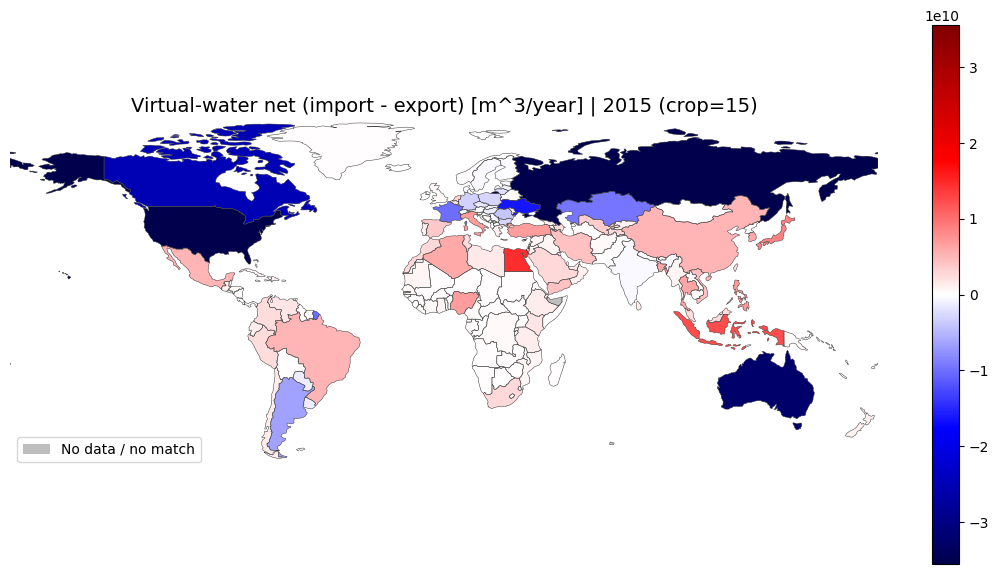

In [22]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def _normalize_zip_shp_path(p: str) -> str:
    p = str(p)
    if p.startswith("zip://"):
        return p
    if ".zip!" in p.lower():
        return "zip://" + p
    return p

def _make_world_iso3_key(world: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    def _clean(s):
        return s.astype(str).str.strip().str.upper()

    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    world["_iso3"] = _clean(world["ISO_A3"])
    invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    if "ADM0_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "ADM0_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    if "SOV_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "SOV_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    world.loc[invalid, "_iso3"] = np.nan
    world["_iso3"] = world["_iso3"].replace({"FR1": "FRA"})
    return world

def plot_vwt_net_import_export_map_debug(
    year: int,
    crop: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    xlim=(-180, 180),
    ylim=(-60, 85),
    top_n_print=20,
    unit="m^3/year",
    cmap="seismic",
    clip_quantile=0.995,
    missing_color="#BEBEBE",
    border_color="#444444",
    border_lw=0.35,
    show_missing_legend=True,
    debug_iso3="FRA",
    print_no_match_samples=30,
    print_df_only_samples=30,
    ussr_until_year=1991,
):
    USSR_ALIASES = {"USSR", "SUN", "USS"}
    USSR_NAME_ALIASES = {"USSR", "SOVIET UNION", "UNION OF SOVIET SOCIALIST REPUBLICS"}

    debug_iso3 = str(debug_iso3).strip().upper()
    if int(year) <= int(ussr_until_year) and debug_iso3 in USSR_ALIASES:
        debug_iso3 = "RUS"

    # 1) VWT
    vwt_path = vwt_npy_template.format(crop=crop, year=year)
    VWTmat = np.load(vwt_path).astype(float)

    if VWTmat.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={VWTmat.shape}")

    nrow, ncol = VWTmat.shape
    if nrow != ncol:
        print(f"[WARN] VWTmat is not square: {VWTmat.shape}. row/colの向きを要確認")

    N = min(nrow, ncol)
    VWTmat = VWTmat[:N, :N]

    print("VWTmat shape:", VWTmat.shape)
    print("VWT file:", vwt_path)

    # 2) country list
    cl = pd.read_excel(country_list_xlsx)

    iso3_col = None
    for c in cl.columns:
        low = str(c).strip().lower()
        if low in ["iso3", "iso_a3", "iso-3", "iso_3"] or "iso3" in low:
            iso3_col = c
            break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    if len(cl) < N:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({N}). country_listの行数が足りない。")

    clN = cl.iloc[:N].copy()
    clN["_iso3_raw"] = clN[iso3_col].astype(str)
    clN["_iso3"] = clN["_iso3_raw"].str.strip().str.upper()

    ISO3_FIX = {
        "FR": "FRA", "UK": "GBR", "EL": "GRC", "SP": "ESP",
        "SW": "SWE", "NO": "NOR", "JA": "JPN", "KO": "KOR", "CH": "CHN",
    }
    clN["_iso3"] = clN["_iso3"].replace(ISO3_FIX)

    country_name_col = None
    for c in clN.columns:
        low = str(c).strip().lower()
        if low in ["country name", "country", "name"]:
            country_name_col = c
            break
    if country_name_col is None:
        country_name_col = clN.columns[0]

    clN["_country_upper"] = clN[country_name_col].astype(str).str.strip().str.upper()
    missing_iso = clN["_iso3"].isin(["", "NAN", "NONE"])
    clN.loc[missing_iso & clN["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    pre_ussr = int(year) <= int(ussr_until_year)

    # 3) import/export/net
    import_by_country = np.nansum(VWTmat, axis=0)  # col sum
    export_by_country = np.nansum(VWTmat, axis=1)  # row sum

    df_net = pd.DataFrame({
        "iso3_raw": clN["_iso3"].values,
        "import": import_by_country,
        "export": export_by_country,
    })

    if pre_ussr:
        df_net["iso3"] = df_net["iso3_raw"].replace({k: "RUS" for k in USSR_ALIASES})
    else:
        df_net["iso3"] = df_net["iso3_raw"]

    df_net = df_net[~df_net["iso3"].isin(["", "NAN", "NONE"])].copy()
    df_net = df_net.groupby("iso3", as_index=False)[["import", "export"]].sum()
    df_net["net"] = df_net["import"] - df_net["export"]

    df_pos = df_net[df_net["net"] > 0].sort_values("net", ascending=False)
    df_neg = df_net[df_net["net"] < 0].sort_values("net", ascending=True)

    print(f"\nTop {top_n_print} net positive (net>0):")
    print(df_pos.head(top_n_print)[["iso3", "import", "export", "net"]])

    print(f"\nTop {top_n_print} net negative (net<0):")
    print(df_neg.head(top_n_print)[["iso3", "import", "export", "net"]])

    # 4) world
    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)
    print("world iso key: ISO_A3 -> ADM0_A3 -> SOV_A3 (fallback)")

    # 5) merge
    m = world.merge(df_net, left_on="_iso3", right_on="iso3", how="left")

    # 5.5) debug
    print("\n" + "=" * 70)
    print(f"[DEBUG] Investigate ISO3 = {debug_iso3}")
    print("=" * 70)

    print(f"[DEBUG] world has {debug_iso3}? ->", (world["_iso3"] == debug_iso3).any())
    if (world["_iso3"] == debug_iso3).any():
        w_rows = world[world["_iso3"] == debug_iso3]
        cols = [c for c in ["NAME", "NAME_EN", "ADMIN", "SOVEREIGNT", "ISO_A3", "ADM0_A3", "SOV_A3", "_iso3"] if c in w_rows.columns]
        print("[DEBUG] world rows for debug_iso3:")
        print(w_rows[cols].head(10))

    print(f"[DEBUG] df_net has {debug_iso3}? ->", (df_net["iso3"] == debug_iso3).any())
    if (df_net["iso3"] == debug_iso3).any():
        print("[DEBUG] df_net row for debug_iso3:")
        print(df_net[df_net["iso3"] == debug_iso3][["iso3", "import", "export", "net"]].head(5))
        raw_rows = clN[clN["_iso3"].isin([debug_iso3, *USSR_ALIASES])][["_iso3_raw", "_iso3", "_country_upper"]].head(20)
        print("[DEBUG] country_list raw->clean candidates:")
        print(raw_rows)
    else:
        candidates = clN[clN["_iso3"].str.contains(debug_iso3[:2], na=False)][["_iso3_raw", "_iso3", "_country_upper"]].head(30)
        print(f"[DEBUG] country_list candidates containing '{debug_iso3[:2]}':")
        print(candidates)

    m_dbg = m[m["_iso3"] == debug_iso3][["_iso3", "iso3", "net", "import", "export"]]
    print("[DEBUG] merged rows for debug_iso3:")
    print(m_dbg.head(10))
    if len(m_dbg) == 0:
        print("[DEBUG] merged has no row for debug_iso3")
    elif m_dbg["net"].isna().all():
        print("[DEBUG] merged net is NaN -> KEY MISMATCH")

    no_match = m[m["_iso3"].notna() & m["net"].isna()][["_iso3"]].drop_duplicates()
    print(f"\n[DEBUG] sample world-iso3 but missing in df_net (no match): n={len(no_match)}")
    print(no_match.head(print_no_match_samples).to_string(index=False))

    net_only = df_net[~df_net["iso3"].isin(world["_iso3"].dropna())][["iso3"]].drop_duplicates()
    print(f"\n[DEBUG] sample df_net iso3 but missing in world: n={len(net_only)}")
    print(net_only.head(print_df_only_samples).to_string(index=False))

    print("=" * 70 + "\n")

    # 6) color scale
    vals = m["net"].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError("net の有効値が無い（マージ失敗 or netが全部NaN）。")

    absvals = np.abs(vals)
    if clip_quantile is not None:
        q = float(clip_quantile)
        if not (0 < q <= 1):
            raise ValueError("clip_quantile must be in (0, 1].")
        vmax = float(np.nanquantile(absvals, q))
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = float(np.nanmax(absvals))
    else:
        vmax = float(np.nanmax(absvals))

    if vmax == 0:
        vmax = 1.0

    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # 7) plot
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()
    ax.set_title(
        f"Virtual-water net (import - export) [{unit}] | {year} (crop={crop})",
        fontsize=14
    )

    m.plot(ax=ax, color=missing_color, linewidth=0.0, edgecolor="none", zorder=1)

    has = np.isfinite(m["net"].astype(float))
    m.loc[has].plot(
        ax=ax,
        column="net",
        cmap=cmap,
        norm=norm,
        linewidth=0.0,
        edgecolor="none",
        legend=True,
        zorder=2
    )

    m.boundary.plot(ax=ax, color=border_color, linewidth=border_lw, zorder=3)

    if show_missing_legend:
        from matplotlib.patches import Patch
        ax.legend(
            handles=[Patch(facecolor=missing_color, edgecolor="none", label="No data / no match")],
            loc="lower left",
            frameon=True
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    plt.show()

    return df_net, m


# 使い方
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

df_net, merged_map = plot_vwt_net_import_export_map_debug(
    year=2015,
    crop=15,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    cmap="seismic",
    clip_quantile=0.995,
    missing_color="#BEBEBE",
    border_color="#444444",
    border_lw=0.35,
    debug_iso3="RUS",
)


# netのアニメーションをつくる

N: 255
world iso key: ISO_A3 -> ADM0_A3 -> SOV_A3 (fallback)
Global scale: vmax=3.59591e+10 (TwoSlopeNorm, clip_quantile=0.995)


Saved GIF: C:\修論研究\VWT_historical_data\net_crop15_1986_2016.gif


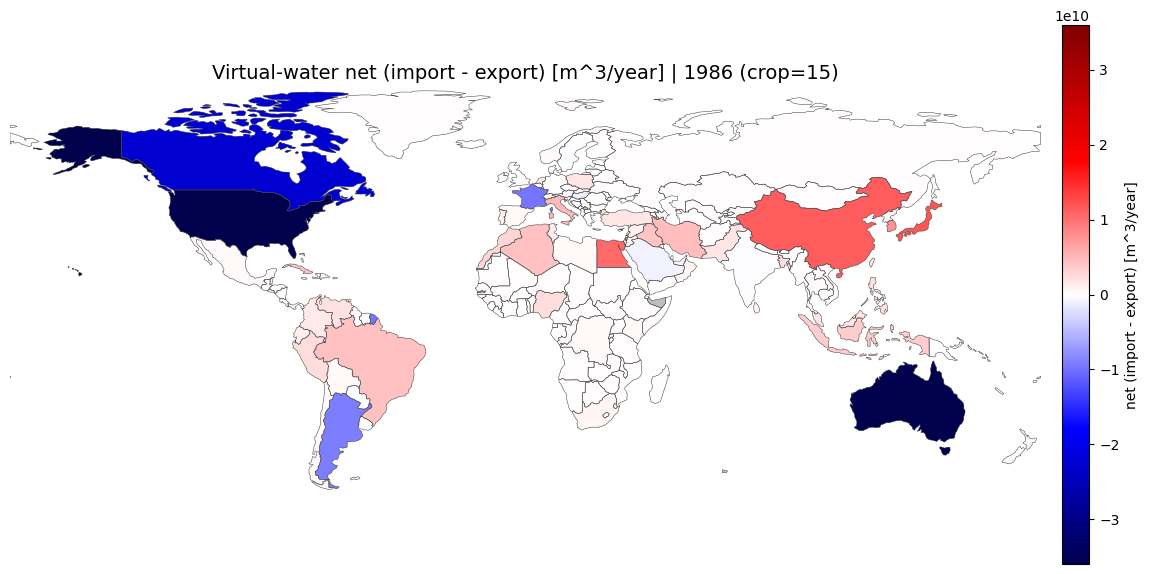

In [16]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from matplotlib.animation import FuncAnimation

def _normalize_zip_shp_path(p: str) -> str:
    """
    gpd.read_file() が読めるように、"xxx.zip!yyy.shp" を "zip://xxx.zip!yyy.shp" に寄せる。
    すでに zip:// が付いてたらそのまま。
    """
    p = str(p)
    if p.startswith("zip://"):
        return p
    if ".zip!" in p.lower():
        return "zip://" + p
    return p

def _make_world_iso3_key(world: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Natural Earth は国によって ISO_A3 が -99（欠損）になるので、
    ISO_A3 -> ADM0_A3 -> SOV_A3 の順でフォールバックして _iso3 を作る。
    """
    def _clean(s):
        return s.astype(str).str.strip().str.upper()

    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    # 1) primary: ISO_A3
    world["_iso3"] = _clean(world["ISO_A3"])
    invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    # 2) fallback: ADM0_A3
    if "ADM0_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "ADM0_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    # 3) fallback: SOV_A3
    if "SOV_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "SOV_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    # cleanup
    world.loc[invalid, "_iso3"] = np.nan

    # 代表的例外（必要なら増やす）
    world["_iso3"] = world["_iso3"].replace({
        "FR1": "FRA",
        # "XKX": "KOS",  # Kosovo をどう扱うかは好み（NEの版による）
    })

    return world

def animate_vwt_net_import_export(
    crop: int,
    year_start: int,
    year_end: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    xlim=(-180, 180),
    ylim=(-60, 85),
    unit="m^3/year",
    fps: int = 6,
    interval_ms: int | None = None,
    out_mp4: str | None = None,
    out_gif: str | None = None,
    dpi: int = 150,
    # 可視化設定
    cmap: str = "seismic",
    clip_quantile: float | None = 0.995,
    missing_color: str = "#BEBEBE",
    border_color: str = "#444444",
    border_lw: float = 0.35,
):
    """
    - crop は固定
    - year_start..year_end をアニメ化
    - net = import - export を正負込みで描画
    - カラーバーは全期間で固定スケール（global vmax）: TwoSlopeNorm(-vmax..+vmax, center=0)
    """
    years = list(range(int(year_start), int(year_end) + 1))
    if interval_ms is None:
        interval_ms = int(1000 / max(1, fps))

    # -------------------------
    # 1) country_list (ISO3)
    # -------------------------
    cl = pd.read_excel(country_list_xlsx)

    iso3_col = None
    for c in cl.columns:
        if str(c).strip().lower() in ["iso3", "iso_a3", "iso-3", "iso_3"]:
            iso3_col = c
            break
    if iso3_col is None:
        for c in cl.columns:
            if "iso3" in str(c).strip().lower():
                iso3_col = c
                break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    # N はVWTのサイズに合わせたいので、まず最初の年を読んでN確定
    vwt0 = np.load(vwt_npy_template.format(crop=crop, year=years[0])).astype(float)
    if vwt0.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt0.shape}")

    N = vwt0.shape[0]
    if vwt0.shape[0] != vwt0.shape[1]:
        print(f"[WARN] VWTmat is not square: {vwt0.shape}. row/colの向きを要確認")

    if len(cl) < N:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({N}). country_listの行数が足りない。")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    ISO3_FIX = {
        "FR": "FRA",
        "UK": "GBR",
        "EL": "GRC",
        "SP": "ESP",
        "SW": "SWE",
        "NO": "NOR",
        "JA": "JPN",
        "KO": "KOR",
    }
    clN["_iso3"] = clN["_iso3"].replace(ISO3_FIX)

    print("N:", N)

    # -------------------------
    # 2) world map load（★修正点：robust iso3 key）
    # -------------------------
    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)
    print("world iso key: ISO_A3 -> ADM0_A3 -> SOV_A3 (fallback)")

    # -------------------------
    # 3) preload net (all years) + global vmax
    # -------------------------
    net_by_year = {}
    global_abs_vals = []

    for y in years:
        vwt_path = vwt_npy_template.format(crop=crop, year=y)
        VWTmat = np.load(vwt_path).astype(float)
        if VWTmat.shape[0] != N or VWTmat.shape[1] != N:
            raise ValueError(f"年{y}のVWTサイズが一致しない: {VWTmat.shape} (expected {N}x{N})")

        import_sum = np.nansum(VWTmat, axis=0)  # col sum
        export_sum = np.nansum(VWTmat, axis=1)  # row sum
        net = (import_sum - export_sum).astype(float)

        net_by_year[y] = net

        vv = net[np.isfinite(net)]
        if vv.size > 0:
            global_abs_vals.append(np.abs(vv))

    if len(global_abs_vals) == 0:
        raise ValueError("[ERROR] 全年で net の有限値が1つも無い（データ/読み込み要確認）")

    global_abs_vals = np.concatenate(global_abs_vals)

    if clip_quantile is not None:
        q = float(clip_quantile)
        if not (0 < q <= 1):
            raise ValueError("clip_quantile must be in (0, 1]. e.g., 0.995")
        vmax = float(np.nanquantile(global_abs_vals, q))
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = float(np.nanmax(global_abs_vals))
    else:
        vmax = float(np.nanmax(global_abs_vals))

    if vmax <= 0 or not np.isfinite(vmax):
        vmax = 1.0

    print(f"Global scale: vmax={vmax:g} (TwoSlopeNorm, clip_quantile={clip_quantile})")

    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # -------------------------
    # 4) figure & fixed colorbar
    # -------------------------
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(f"net (import - export) [{unit}]")

    # -------------------------
    # 5) animation update
    # -------------------------
    def update(frame_i: int):
        y = years[frame_i]
        ax.cla()
        ax.set_axis_off()
        ax.set_title(
            f"Virtual-water net (import - export) [{unit}] | {y} (crop={crop})",
            fontsize=14
        )

        net = net_by_year[y]
        df = pd.DataFrame({"iso3": clN["_iso3"].values, "net": net})

        m = world.merge(df, left_on="_iso3", right_on="iso3", how="left")

        # base: no data/no match
        m.plot(ax=ax, color=missing_color, linewidth=0.0, edgecolor="none")

        # net exists
        has = np.isfinite(m["net"].astype(float))
        if has.any():
            m.loc[has].plot(
                ax=ax,
                column="net",
                cmap=cmap,
                norm=norm,          # ★固定スケール
                linewidth=0.0,
                edgecolor="none",
                legend=False,
            )

        # borders
        m.boundary.plot(ax=ax, color=border_color, linewidth=border_lw)

        # ★ガタガタ防止：座標系を毎フレーム固定
        ax.set_aspect("equal")
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        return []

    anim = FuncAnimation(
        fig,
        update,
        frames=len(years),
        interval=interval_ms,
        blit=False
    )

    # -------------------------
    # 6) save (optional)
    # -------------------------
    if out_mp4:
        anim.save(
            out_mp4,
            writer="ffmpeg",
            fps=fps,
            dpi=dpi,
            savefig_kwargs={"bbox_inches": "tight", "pad_inches": 0.05},
        )
        print("Saved MP4:", out_mp4)

    if out_gif:
        anim.save(
            out_gif,
            writer="pillow",
            fps=fps,
            dpi=dpi,
            savefig_kwargs={"bbox_inches": "tight", "pad_inches": 0.05},
        )
        print("Saved GIF:", out_gif)

    # plt.show()
    return anim


# =========================
# 使い方（ここだけ変えればOK）
# =========================
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

anim = animate_vwt_net_import_export(
    crop=15,
    year_start=1986,
    year_end=2016,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    fps=6,
    out_gif=r"C:\修論研究\VWT_historical_data\net_crop15_1986_2016.gif",
    cmap="seismic",
    clip_quantile=0.995,
)

N: 255
world iso key: ISO_A3 -> ADM0_A3 -> SOV_A3 (fallback)


Global scale: vmax=3.72978e+10 (TwoSlopeNorm, clip_quantile=0.995)
Saved GIF: C:\修論研究\VWT_historical_data\net_crop15_1986_2016.gif


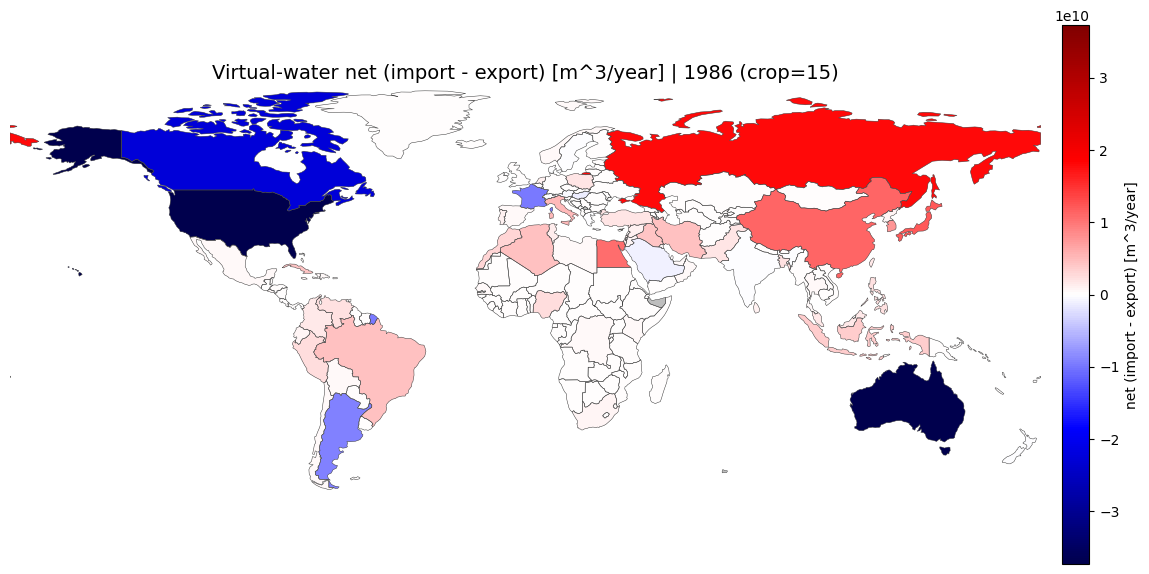

In [23]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from matplotlib.animation import FuncAnimation

def _normalize_zip_shp_path(p: str) -> str:
    p = str(p)
    if p.startswith("zip://"):
        return p
    if ".zip!" in p.lower():
        return "zip://" + p
    return p

def _make_world_iso3_key(world: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    def _clean(s):
        return s.astype(str).str.strip().str.upper()

    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    world["_iso3"] = _clean(world["ISO_A3"])
    invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    if "ADM0_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "ADM0_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    if "SOV_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "SOV_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    world.loc[invalid, "_iso3"] = np.nan
    world["_iso3"] = world["_iso3"].replace({"FR1": "FRA"})
    return world

def animate_vwt_net_import_export(
    crop: int,
    year_start: int,
    year_end: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    xlim=(-180, 180),
    ylim=(-60, 85),
    unit="m^3/year",
    fps: int = 6,
    interval_ms: int | None = None,
    out_mp4: str | None = None,
    out_gif: str | None = None,
    dpi: int = 150,
    cmap: str = "seismic",
    clip_quantile: float | None = 0.995,
    missing_color: str = "#BEBEBE",
    border_color: str = "#444444",
    border_lw: float = 0.35,
    ussr_until_year: int = 1991,
):
    USSR_ALIASES = {"USSR", "SUN", "USS"}
    USSR_NAME_ALIASES = {"USSR", "SOVIET UNION", "UNION OF SOVIET SOCIALIST REPUBLICS"}

    years = list(range(int(year_start), int(year_end) + 1))
    if len(years) == 0:
        raise ValueError("year_start <= year_end になるように指定して。")
    if interval_ms is None:
        interval_ms = int(1000 / max(1, fps))

    # 1) country_list
    cl = pd.read_excel(country_list_xlsx)

    iso3_col = None
    for c in cl.columns:
        low = str(c).strip().lower()
        if low in ["iso3", "iso_a3", "iso-3", "iso_3"] or "iso3" in low:
            iso3_col = c
            break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    vwt0 = np.load(vwt_npy_template.format(crop=crop, year=years[0])).astype(float)
    if vwt0.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt0.shape}")

    N = vwt0.shape[0]
    if vwt0.shape[0] != vwt0.shape[1]:
        print(f"[WARN] VWTmat is not square: {vwt0.shape}. row/colの向きを要確認")

    if len(cl) < N:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({N}). country_listの行数が足りない。")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    ISO3_FIX = {
        "FR": "FRA", "UK": "GBR", "EL": "GRC", "SP": "ESP",
        "SW": "SWE", "NO": "NOR", "JA": "JPN", "KO": "KOR", "CH": "CHN",
    }
    clN["_iso3"] = clN["_iso3"].replace(ISO3_FIX)

    country_name_col = None
    for c in clN.columns:
        low = str(c).strip().lower()
        if low in ["country name", "country", "name"]:
            country_name_col = c
            break
    if country_name_col is None:
        country_name_col = clN.columns[0]

    clN["_country_upper"] = clN[country_name_col].astype(str).str.strip().str.upper()
    missing_iso = clN["_iso3"].isin(["", "NAN", "NONE"])
    clN.loc[missing_iso & clN["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    print("N:", N)

    # 2) world
    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)
    print("world iso key: ISO_A3 -> ADM0_A3 -> SOV_A3 (fallback)")

    # 3) preload net
    net_df_by_year = {}
    global_abs_vals = []

    for y in years:
        VWTmat = np.load(vwt_npy_template.format(crop=crop, year=y)).astype(float)
        if VWTmat.shape[0] != N or VWTmat.shape[1] != N:
            raise ValueError(f"年{y}のVWTサイズが一致しない: {VWTmat.shape} (expected {N}x{N})")

        import_sum = np.nansum(VWTmat, axis=0)
        export_sum = np.nansum(VWTmat, axis=1)

        df = pd.DataFrame({
            "iso3_raw": clN["_iso3"].values,
            "import": import_sum,
            "export": export_sum,
        })

        if y <= int(ussr_until_year):
            df["iso3"] = df["iso3_raw"].replace({k: "RUS" for k in USSR_ALIASES})
        else:
            df["iso3"] = df["iso3_raw"]

        df = df[~df["iso3"].isin(["", "NAN", "NONE"])].copy()
        df = df.groupby("iso3", as_index=False)[["import", "export"]].sum()
        df["net"] = df["import"] - df["export"]

        net_df_by_year[y] = df[["iso3", "net"]]

        vv = df["net"].to_numpy(dtype=float)
        vv = vv[np.isfinite(vv)]
        if vv.size > 0:
            global_abs_vals.append(np.abs(vv))

    if len(global_abs_vals) == 0:
        raise ValueError("[ERROR] 全年で net の有限値が1つも無い（データ/読み込み要確認）")

    global_abs_vals = np.concatenate(global_abs_vals)

    if clip_quantile is not None:
        q = float(clip_quantile)
        if not (0 < q <= 1):
            raise ValueError("clip_quantile must be in (0, 1]. e.g., 0.995")
        vmax = float(np.nanquantile(global_abs_vals, q))
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = float(np.nanmax(global_abs_vals))
    else:
        vmax = float(np.nanmax(global_abs_vals))

    if vmax <= 0 or not np.isfinite(vmax):
        vmax = 1.0

    print(f"Global scale: vmax={vmax:g} (TwoSlopeNorm, clip_quantile={clip_quantile})")
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # 4) figure
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(f"net (import - export) [{unit}]")

    # 5) update
    def update(frame_i: int):
        y = years[frame_i]
        ax.cla()
        ax.set_axis_off()
        ax.set_title(
            f"Virtual-water net (import - export) [{unit}] | {y} (crop={crop})",
            fontsize=14
        )

        df = net_df_by_year[y]
        m = world.merge(df, left_on="_iso3", right_on="iso3", how="left")

        m.plot(ax=ax, color=missing_color, linewidth=0.0, edgecolor="none")

        has = np.isfinite(m["net"].astype(float))
        if has.any():
            m.loc[has].plot(
                ax=ax,
                column="net",
                cmap=cmap,
                norm=norm,
                linewidth=0.0,
                edgecolor="none",
                legend=False,
            )

        m.boundary.plot(ax=ax, color=border_color, linewidth=border_lw)

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        return []

    anim = FuncAnimation(fig, update, frames=len(years), interval=interval_ms, blit=False)

    # 6) save
    if out_mp4:
        anim.save(out_mp4, writer="ffmpeg", fps=fps, dpi=dpi,
                  savefig_kwargs={"bbox_inches": "tight", "pad_inches": 0.05})
        print("Saved MP4:", out_mp4)

    if out_gif:
        anim.save(out_gif, writer="pillow", fps=fps, dpi=dpi,
                  savefig_kwargs={"bbox_inches": "tight", "pad_inches": 0.05})
        print("Saved GIF:", out_gif)

    return anim


# 使い方
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

anim = animate_vwt_net_import_export(
    crop=15,
    year_start=1986,
    year_end=2016,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    fps=6,
    out_gif=r"C:\修論研究\VWT_historical_data\net_crop15_1986_2016.gif",
    cmap="seismic",
    clip_quantile=0.995,
)


# net,export,import時系列グラフを描く。（国、作物ごと）

Country index (RUS mode): pre<=1991 -> 241, post -> 187
Country label: Russia
Years: 1986 - 2016


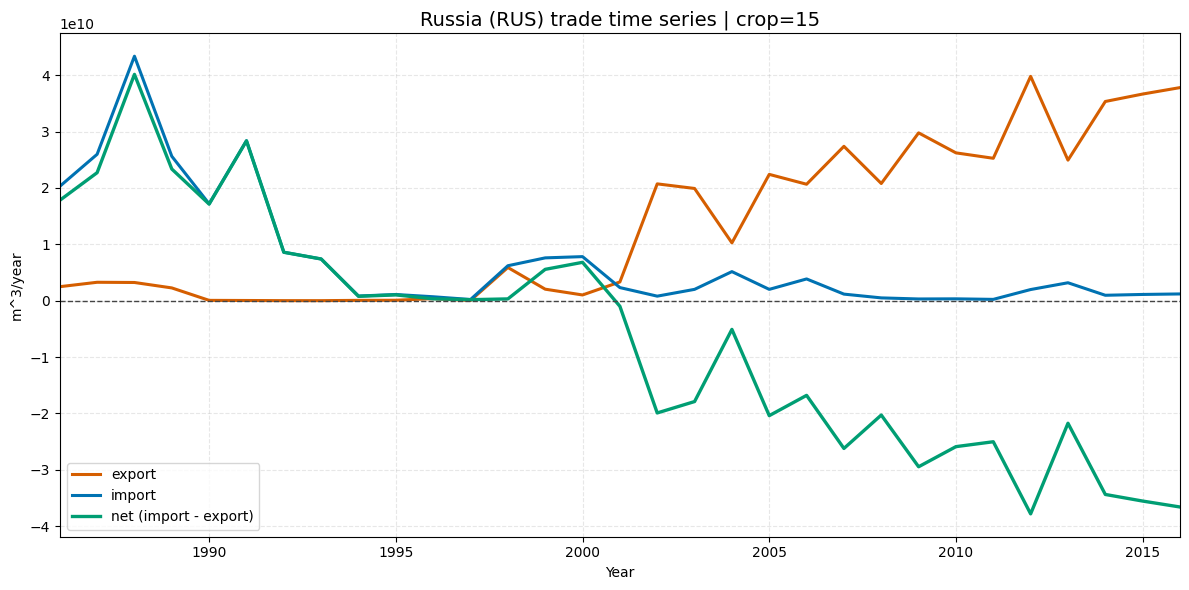

,year,iso3,country,crop,export,import,net
0,1986,RUS,Russia,15,2.477971e+09,2.027443e+10,1.779646e+10
1,1987,RUS,Russia,15,3.260847e+09,2.596187e+10,2.270102e+10
2,1988,RUS,Russia,15,3.222855e+09,4.335831e+10,4.013546e+10
3,1989,RUS,Russia,15,2.259564e+09,2.560813e+10,2.334856e+10
4,1990,RUS,Russia,15,5.235702e+07,1.717603e+10,1.712367e+10


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_vwt_trade_timeseries(
    country_iso3: str,
    crop: int,
    year_start: int,
    year_end: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    unit: str = "m^3/year",
    figsize=(12, 6),
    out_png: str | None = None,
    ussr_until_year: int = 1991,
):
    """
    指定した国・作物について、export / import / net(import-export) の時系列を描く。
    VWTmat は row=exporter, col=importer 前提。
    RUS指定時は year<=ussr_until_year で USSR 行を優先利用。
    """
    USSR_ALIASES = {"USSR", "SUN", "USS"}
    USSR_NAME_ALIASES = {"USSR", "SOVIET UNION", "UNION OF SOVIET SOCIALIST REPUBLICS"}

    country_iso3 = str(country_iso3).strip().upper()
    if country_iso3 in USSR_ALIASES:
        country_iso3 = "RUS"

    years = list(range(int(year_start), int(year_end) + 1))
    if len(years) == 0:
        raise ValueError("year_start <= year_end になるように指定して。")

    cl = pd.read_excel(country_list_xlsx)

    iso3_col = None
    for c in cl.columns:
        low = str(c).strip().lower()
        if low in ["iso3", "iso_a3", "iso-3", "iso_3"] or "iso3" in low:
            iso3_col = c
            break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    country_name_col = None
    for c in cl.columns:
        name = str(c).strip().lower()
        if name in ["country name", "country", "name"]:
            country_name_col = c
            break
    if country_name_col is None:
        country_name_col = cl.columns[0]

    vwt0 = np.load(vwt_npy_template.format(crop=crop, year=years[0])).astype(float)
    if vwt0.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt0.shape}")

    if vwt0.shape[0] != vwt0.shape[1]:
        print(f"[WARN] VWTmat is not square: {vwt0.shape}. row/colの向きを要確認")

    N = min(vwt0.shape[0], vwt0.shape[1])
    if len(cl) < N:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({N}). country_listの行数が足りない。")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    ISO3_FIX = {
        "FR": "FRA", "UK": "GBR", "EL": "GRC", "SP": "ESP",
        "SW": "SWE", "NO": "NOR", "JA": "JPN", "KO": "KOR", "CH": "CHN",
    }
    clN["_iso3"] = clN["_iso3"].replace(ISO3_FIX)

    # ISO3欠損のUSSRを国名で補完
    clN["_country_upper"] = clN[country_name_col].astype(str).str.strip().str.upper()
    missing_iso = clN["_iso3"].isin(["", "NAN", "NONE"])
    clN.loc[missing_iso & clN["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    # 対象インデックス決定
    ussr_hits = clN.index[clN["_iso3"].isin(USSR_ALIASES)] if country_iso3 == "RUS" else []
    if country_iso3 == "RUS":
        rus_hits = clN.index[clN["_iso3"] == "RUS"]
        if len(rus_hits) == 0 and len(ussr_hits) == 0:
            raise ValueError("RUS/USSR が country_list の先頭N行に見つからない。")

        idx_post = int(rus_hits[0]) if len(rus_hits) > 0 else int(ussr_hits[0])  # 1992以降
        idx_pre = int(ussr_hits[0]) if len(ussr_hits) > 0 else idx_post           # 1991以前
        country_label = "Russia"
        print(f"Country index (RUS mode): pre<={ussr_until_year} -> {idx_pre}, post -> {idx_post}")
    else:
        hit = clN.index[clN["_iso3"] == country_iso3]
        if len(hit) == 0:
            raise ValueError(
                f"country_iso3={country_iso3} が country_list の先頭N行に見つからない。\n"
                f"・country_listがVWT順になっているか\n"
                f"・ISO3列の中身が正しいか\n"
                f"・country_iso3の表記(USA/JPNなど)が正しいか を確認して。"
            )
        idx_post = int(hit[0])
        idx_pre = idx_post
        country_label = str(clN.loc[idx_post, country_name_col]).strip()

    print("Country label:", country_label)
    print("Years:", years[0], "-", years[-1])

    rows = []
    has_ussr = len(ussr_hits) > 0 if country_iso3 == "RUS" else False

    for y in years:
        vwt_path = vwt_npy_template.format(crop=crop, year=y)
        VWTmat = np.load(vwt_path).astype(float)
        if VWTmat.ndim != 2:
            raise ValueError(f"年{y}のVWTmat must be 2D. got shape={VWTmat.shape}")

        if min(VWTmat.shape[0], VWTmat.shape[1]) != N:
            raise ValueError(f"年{y}のVWTサイズが一致しない: {VWTmat.shape} (expected {N}x{N})")

        VWTmat = VWTmat[:N, :N]

        use_pre = (country_iso3 == "RUS" and y <= int(ussr_until_year) and has_ussr)
        country_index = idx_pre if use_pre else idx_post

        export_total = float(np.nansum(VWTmat[country_index, :]))
        import_total = float(np.nansum(VWTmat[:, country_index]))
        net_total = import_total - export_total

        rows.append(
            {
                "year": y,
                "iso3": country_iso3,
                "country": country_label,
                "crop": crop,
                "export": export_total,
                "import": import_total,
                "net": net_total,
            }
        )

    df_ts = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df_ts["year"], df_ts["export"], label="export", color="#D55E00", linewidth=2.2)
    ax.plot(df_ts["year"], df_ts["import"], label="import", color="#0072B2", linewidth=2.2)
    ax.plot(df_ts["year"], df_ts["net"], label="net (import - export)", color="#009E73", linewidth=2.4)
    ax.axhline(0.0, color="#444444", linewidth=1.0, linestyle="--")

    ax.set_title(f"{country_label} ({country_iso3}) trade time series | crop={crop}", fontsize=14)
    ax.set_xlabel("Year")
    ax.set_ylabel(unit)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend()
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_xlim(years[0], years[-1])
    plt.tight_layout()

    if out_png is not None:
        fig.savefig(out_png, dpi=200, bbox_inches="tight")
        print("Saved PNG:", out_png)

    plt.show()
    return df_ts


COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"

df_ts = plot_vwt_trade_timeseries(
    country_iso3="RUS",
    crop=15,
    year_start=1986,
    year_end=2016,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
)

df_ts.head()


# 仮想水輸出量総量の時系列変化を描く（↓ロシアのお世話済）

In [31]:
rus_chk = df_long[df_long["iso3"] == "RUS"].sort_values("year")
print(rus_chk[["year", "export"]].head(10))
print(rus_chk[rus_chk["year"] <= 1991][["year", "export"]])
print(df_long[(df_long["year"] <= 1991) & (df_long["iso3"].isin(["USSR","SUN","USS"]))].shape)


      year        export
173   1986  5.531745e+08
403   1987  2.431114e+08
633   1988  4.897881e+07
863   1989  3.492197e+08
1093  1990  7.188849e+07
1323  1991  7.751087e+07
1553  1992  1.909794e+07
1784  1993  1.717343e+06
2015  1994  9.233251e+07
2246  1995  4.626417e+07
      year        export
173   1986  5.531745e+08
403   1987  2.431114e+08
633   1988  4.897881e+07
863   1989  3.492197e+08
1093  1990  7.188849e+07
1323  1991  7.751087e+07
(0, 4)


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_vwt_export_timeseries_all_countries(
    crop,
    year_start,
    year_end,
    country_list_xlsx,
    vwt_npy_template,
    unit="m^3/year",
    figsize=(15, 8),
    alpha=0.35,
    lw=0.8,
    ussr_until_year=1991,
    top_n_label=10,
    label_right_pad=0.6,
):
    """
    指定作物について、全ての国の仮想水輸出総量の時系列を重ね描きする。
    前提: VWTmat は row=exporter, col=importer
    """
    USSR_ALIASES = {"USSR", "SUN", "USS"}
    USSR_NAME_ALIASES = {"USSR", "SOVIET UNION", "UNION OF SOVIET SOCIALIST REPUBLICS"}

    years = list(range(int(year_start), int(year_end) + 1))
    if len(years) == 0:
        raise ValueError("year_start <= year_end になるように指定して。")

    cl = pd.read_excel(country_list_xlsx)

    # ISO3列検出
    iso3_col = None
    for c in cl.columns:
        low = str(c).strip().lower()
        if low in ["iso3", "iso_a3", "iso-3", "iso_3"] or "iso3" in low:
            iso3_col = c
            break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    # 国名列検出
    country_name_col = None
    for c in cl.columns:
        low = str(c).strip().lower()
        if low in ["country name", "country", "name"]:
            country_name_col = c
            break
    if country_name_col is None:
        country_name_col = cl.columns[0]

    # N確定
    vwt0 = np.load(vwt_npy_template.format(crop=crop, year=years[0])).astype(float)
    if vwt0.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt0.shape}")

    N = min(vwt0.shape[0], vwt0.shape[1])
    if len(cl) < N:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({N}). country_listの行数が足りない。")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    ISO3_FIX = {
        "FR": "FRA",
        "UK": "GBR",
        "EL": "GRC",
        "SP": "ESP",
        "SW": "SWE",
        "NO": "NOR",
        "JA": "JPN",
        "KO": "KOR",
        "CH": "CHN",
    }
    clN["_iso3"] = clN["_iso3"].replace(ISO3_FIX)

    clN["_country"] = clN[country_name_col].astype(str).str.strip()
    clN["_country_upper"] = clN["_country"].str.upper()

    # ISO3欠損のUSSRを補完
    missing_iso = clN["_iso3"].isin(["", "NAN", "NONE"])
    clN.loc[missing_iso & clN["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    # 年ごとの輸出総量（row合計）
    rows = []
    for y in years:
        VWTmat = np.load(vwt_npy_template.format(crop=crop, year=y)).astype(float)
        if VWTmat.ndim != 2:
            raise ValueError(f"年{y}のVWTmat must be 2D. got shape={VWTmat.shape}")

        VWTmat = VWTmat[:N, :N]
        export_totals = np.nansum(VWTmat, axis=1).astype(float)

        tmp = pd.DataFrame({
            "year": y,
            "iso3": clN["_iso3"].values,
            "country": clN["_country"].values,
            "export": export_totals,
        })
        rows.append(tmp)

    df_long = pd.concat(rows, ignore_index=True)
    df_long["iso3"] = df_long["iso3"].astype(str).str.strip().str.upper()
    df_long["country"] = df_long["country"].astype(str).str.strip()

    # 無効ISO3除外
    df_long = df_long[~df_long["iso3"].isin(["", "NAN", "NONE"])].copy()

    # <=1991 は USSR/SUN/USS を RUS に統合
    pre_mask = df_long["year"] <= int(ussr_until_year)
    country_upper = df_long["country"].str.upper()

    is_ussr = df_long["iso3"].isin(USSR_ALIASES) | country_upper.isin(USSR_NAME_ALIASES)
    is_rus = df_long["iso3"].isin({"RUS", "RU"})

    years_with_ussr = set(df_long.loc[pre_mask & is_ussr, "year"].unique().tolist())

    # 同年にUSSRがあるpre期間のRUSは落として二重計上回避
    if len(years_with_ussr) > 0:
        drop_rus_mask = pre_mask & is_rus & df_long["year"].isin(years_with_ussr)
        df_long = df_long.loc[~drop_rus_mask].copy()

    replace_mask = pre_mask & is_ussr
    df_long.loc[replace_mask, "iso3"] = "RUS"
    df_long.loc[replace_mask, "country"] = "Russia"

    # 集計
    df_long = (
        df_long
        .groupby(["year", "iso3", "country"], as_index=False)["export"]
        .sum()
    )

    # 期間合計（iso3単位）←重複ISOを作らない
    country_order = (
        df_long
        .groupby("iso3", as_index=False)["export"]
        .sum()
        .sort_values("export", ascending=False)
    )

    valid_iso3 = country_order.loc[country_order["export"] > 0, "iso3"].tolist()
    df_long = df_long[df_long["iso3"].isin(valid_iso3)].copy()

    # 広い形式
    wide = df_long.pivot_table(
        index="year",
        columns="iso3",
        values="export",
        aggfunc="sum"
    )

    # 念のため重複列除去
    wide = wide.loc[:, ~wide.columns.duplicated()]

    ordered_iso3 = [x for x in country_order["iso3"].tolist() if x in wide.columns]
    wide = wide[ordered_iso3]

    # ---- 描画 ----
    top_iso = ordered_iso3[:top_n_label]

    fig, ax = plt.subplots(figsize=figsize)

    # 上位のみカラー、他は薄グレー
    top_colors_arr = plt.cm.tab10(np.linspace(0, 1, max(len(top_iso), 1)))
    top_color_map = {iso: top_colors_arr[i] for i, iso in enumerate(top_iso)}

    for iso3 in wide.columns:
        if iso3 in top_color_map:
            ax.plot(
                wide.index, wide[iso3],
                color=top_color_map[iso3],
                alpha=0.95,
                linewidth=lw * 2.2,
                zorder=3,
            )
        else:
            ax.plot(
                wide.index, wide[iso3],
                color="#B0B0B0",
                alpha=0.25,
                linewidth=lw,
                zorder=1,
            )

    # 右端に上位ISOラベル
    label_rows = []
    for iso3 in top_iso:
        s = wide[iso3]
        if isinstance(s, pd.DataFrame):   # 保険
            s = s.sum(axis=1)
        s = s.dropna().sort_index()
        if s.empty:
            continue
        x_last = int(s.index[-1])
        y_last = float(s.iloc[-1])
        label_rows.append([y_last, x_last, iso3])

    # 簡易重なり回避
    if len(label_rows) > 1:
        label_rows.sort(key=lambda x: x[0])
        ymin = float(np.nanmin(wide.to_numpy()))
        ymax = float(np.nanmax(wide.to_numpy()))
        min_sep = max((ymax - ymin) * 0.015, 1e-12)
        for i in range(1, len(label_rows)):
            if label_rows[i][0] - label_rows[i - 1][0] < min_sep:
                label_rows[i][0] = label_rows[i - 1][0] + min_sep

    for y_lab, x_last, iso3 in label_rows:
        ax.text(
            x_last + label_right_pad,
            y_lab,
            iso3,
            color=top_color_map[iso3],
            fontsize=9,
            va="center",
            ha="left",
            zorder=4,
        )

    ax.set_title(f"Virtual-water export time series of all countries | crop={crop}", fontsize=14)
    ax.set_xlabel("Year")
    ax.set_ylabel(unit)
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_xlim(years[0], years[-1] + 2)

    plt.tight_layout()
    plt.show()

    return df_long, wide


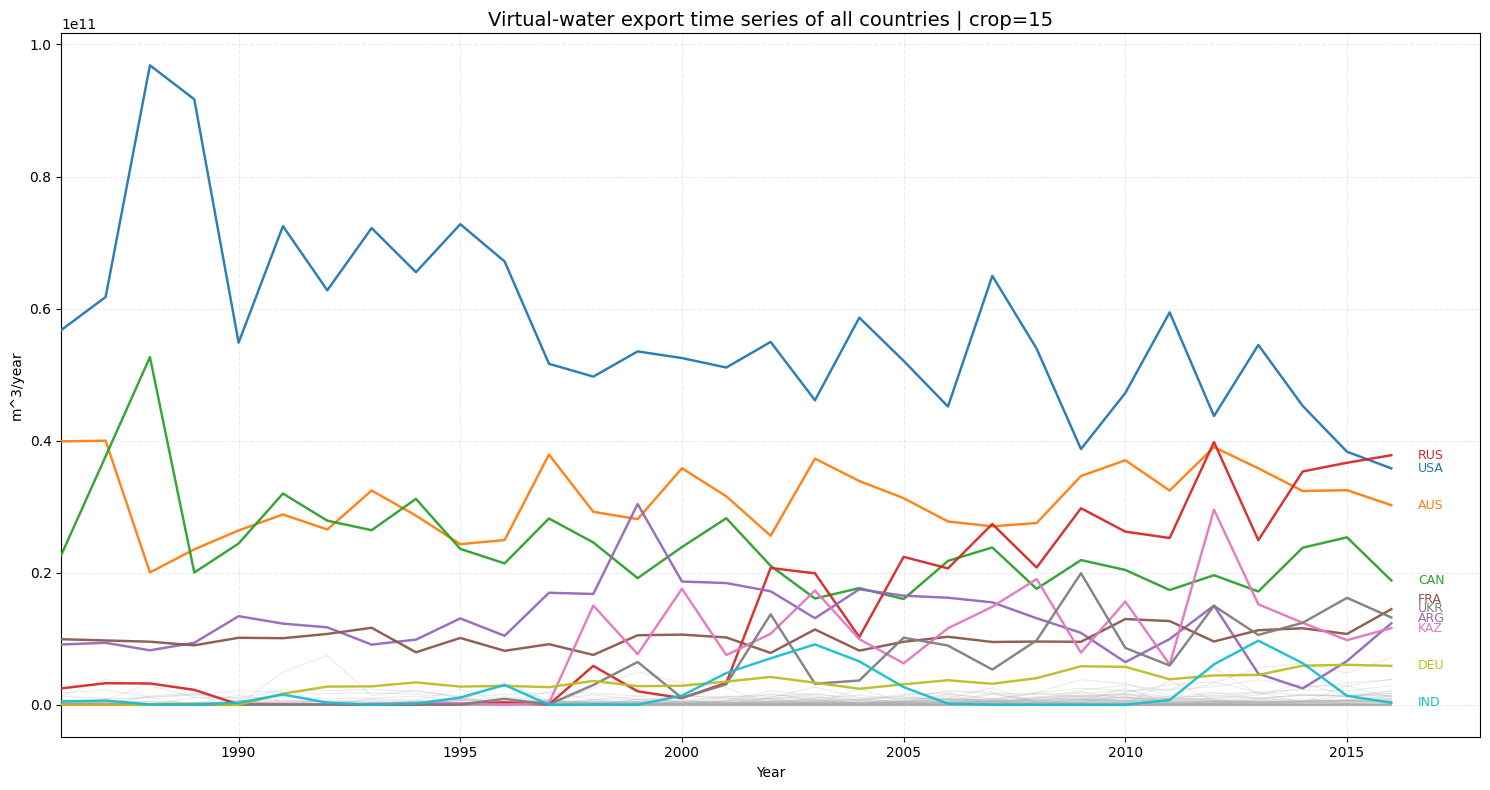

In [36]:
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"

df_long, df_wide = plot_vwt_export_timeseries_all_countries(
    crop=15,
    year_start=1986,
    year_end=2016,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    top_n_label=10,
)


# importバージョン

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_vwt_import_timeseries_all_countries(
    crop,
    year_start,
    year_end,
    country_list_xlsx,
    vwt_npy_template,
    unit="m^3/year",
    figsize=(15, 8),
    alpha=0.35,
    lw=0.8,
    ussr_until_year=1991,
    top_n_label=10,
    label_right_pad=0.6,
):
    """
    指定作物について、全ての国の仮想水輸入総量の時系列を重ね描きする。
    前提: VWTmat は row=exporter, col=importer
    """
    USSR_ALIASES = {"USSR", "SUN", "USS"}
    USSR_NAME_ALIASES = {"USSR", "SOVIET UNION", "UNION OF SOVIET SOCIALIST REPUBLICS"}

    years = list(range(int(year_start), int(year_end) + 1))
    if len(years) == 0:
        raise ValueError("year_start <= year_end になるように指定して。")

    cl = pd.read_excel(country_list_xlsx)

    # ISO3列検出
    iso3_col = None
    for c in cl.columns:
        low = str(c).strip().lower()
        if low in ["iso3", "iso_a3", "iso-3", "iso_3"] or "iso3" in low:
            iso3_col = c
            break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    # 国名列検出
    country_name_col = None
    for c in cl.columns:
        low = str(c).strip().lower()
        if low in ["country name", "country", "name"]:
            country_name_col = c
            break
    if country_name_col is None:
        country_name_col = cl.columns[0]

    # N確定
    vwt0 = np.load(vwt_npy_template.format(crop=crop, year=years[0])).astype(float)
    if vwt0.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt0.shape}")

    N = min(vwt0.shape[0], vwt0.shape[1])
    if len(cl) < N:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({N}). country_listの行数が足りない。")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    ISO3_FIX = {
        "FR": "FRA",
        "UK": "GBR",
        "EL": "GRC",
        "SP": "ESP",
        "SW": "SWE",
        "NO": "NOR",
        "JA": "JPN",
        "KO": "KOR",
        "CH": "CHN",
    }
    clN["_iso3"] = clN["_iso3"].replace(ISO3_FIX)

    clN["_country"] = clN[country_name_col].astype(str).str.strip()
    clN["_country_upper"] = clN["_country"].str.upper()

    # ISO3欠損のUSSRを補完
    missing_iso = clN["_iso3"].isin(["", "NAN", "NONE"])
    clN.loc[missing_iso & clN["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    # 年ごとの輸入総量（col合計）
    rows = []
    for y in years:
        VWTmat = np.load(vwt_npy_template.format(crop=crop, year=y)).astype(float)
        if VWTmat.ndim != 2:
            raise ValueError(f"年{y}のVWTmat must be 2D. got shape={VWTmat.shape}")

        VWTmat = VWTmat[:N, :N]
        import_totals = np.nansum(VWTmat, axis=0).astype(float)

        tmp = pd.DataFrame({
            "year": y,
            "iso3": clN["_iso3"].values,
            "country": clN["_country"].values,
            "import": import_totals,
        })
        rows.append(tmp)

    df_long = pd.concat(rows, ignore_index=True)
    df_long["iso3"] = df_long["iso3"].astype(str).str.strip().str.upper()
    df_long["country"] = df_long["country"].astype(str).str.strip()

    # 無効ISO3除外
    df_long = df_long[~df_long["iso3"].isin(["", "NAN", "NONE"])].copy()

    # <=1991 は USSR/SUN/USS を RUS に統合
    pre_mask = df_long["year"] <= int(ussr_until_year)
    country_upper = df_long["country"].str.upper()

    is_ussr = df_long["iso3"].isin(USSR_ALIASES) | country_upper.isin(USSR_NAME_ALIASES)
    is_rus = df_long["iso3"].isin({"RUS", "RU"})

    years_with_ussr = set(df_long.loc[pre_mask & is_ussr, "year"].unique().tolist())

    # 同年にUSSRがあるpre期間のRUSは落として二重計上回避
    if len(years_with_ussr) > 0:
        drop_rus_mask = pre_mask & is_rus & df_long["year"].isin(years_with_ussr)
        df_long = df_long.loc[~drop_rus_mask].copy()

    replace_mask = pre_mask & is_ussr
    df_long.loc[replace_mask, "iso3"] = "RUS"
    df_long.loc[replace_mask, "country"] = "Russia"

    # 集計
    df_long = (
        df_long
        .groupby(["year", "iso3", "country"], as_index=False)["import"]
        .sum()
    )

    # 期間合計（iso3単位）
    country_order = (
        df_long
        .groupby("iso3", as_index=False)["import"]
        .sum()
        .sort_values("import", ascending=False)
    )

    valid_iso3 = country_order.loc[country_order["import"] > 0, "iso3"].tolist()
    df_long = df_long[df_long["iso3"].isin(valid_iso3)].copy()

    # 広い形式
    wide = df_long.pivot_table(
        index="year",
        columns="iso3",
        values="import",
        aggfunc="sum"
    )

    wide = wide.loc[:, ~wide.columns.duplicated()]

    ordered_iso3 = [x for x in country_order["iso3"].tolist() if x in wide.columns]
    wide = wide[ordered_iso3]

    # ---- 描画 ----
    top_iso = ordered_iso3[:top_n_label]

    fig, ax = plt.subplots(figsize=figsize)

    top_colors_arr = plt.cm.tab10(np.linspace(0, 1, max(len(top_iso), 1)))
    top_color_map = {iso: top_colors_arr[i] for i, iso in enumerate(top_iso)}

    for iso3 in wide.columns:
        if iso3 in top_color_map:
            ax.plot(
                wide.index, wide[iso3],
                color=top_color_map[iso3],
                alpha=0.95,
                linewidth=lw * 2.2,
                zorder=3,
            )
        else:
            ax.plot(
                wide.index, wide[iso3],
                color="#B0B0B0",
                alpha=0.25,
                linewidth=lw,
                zorder=1,
            )

    # 右端ラベル
    label_rows = []
    for iso3 in top_iso:
        s = wide[iso3]
        if isinstance(s, pd.DataFrame):
            s = s.sum(axis=1)
        s = s.dropna().sort_index()
        if s.empty:
            continue
        x_last = int(s.index[-1])
        y_last = float(s.iloc[-1])
        label_rows.append([y_last, x_last, iso3])

    if len(label_rows) > 1:
        label_rows.sort(key=lambda x: x[0])
        ymin = float(np.nanmin(wide.to_numpy()))
        ymax = float(np.nanmax(wide.to_numpy()))
        min_sep = max((ymax - ymin) * 0.015, 1e-12)
        for i in range(1, len(label_rows)):
            if label_rows[i][0] - label_rows[i - 1][0] < min_sep:
                label_rows[i][0] = label_rows[i - 1][0] + min_sep

    for y_lab, x_last, iso3 in label_rows:
        ax.text(
            x_last + label_right_pad,
            y_lab,
            iso3,
            color=top_color_map[iso3],
            fontsize=9,
            va="center",
            ha="left",
            zorder=4,
        )

    ax.set_title(f"Virtual-water import time series of all countries | crop={crop}", fontsize=14)
    ax.set_xlabel("Year")
    ax.set_ylabel(unit)
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_xlim(years[0], years[-1] + 2)

    plt.tight_layout()
    plt.show()

    return df_long, wide


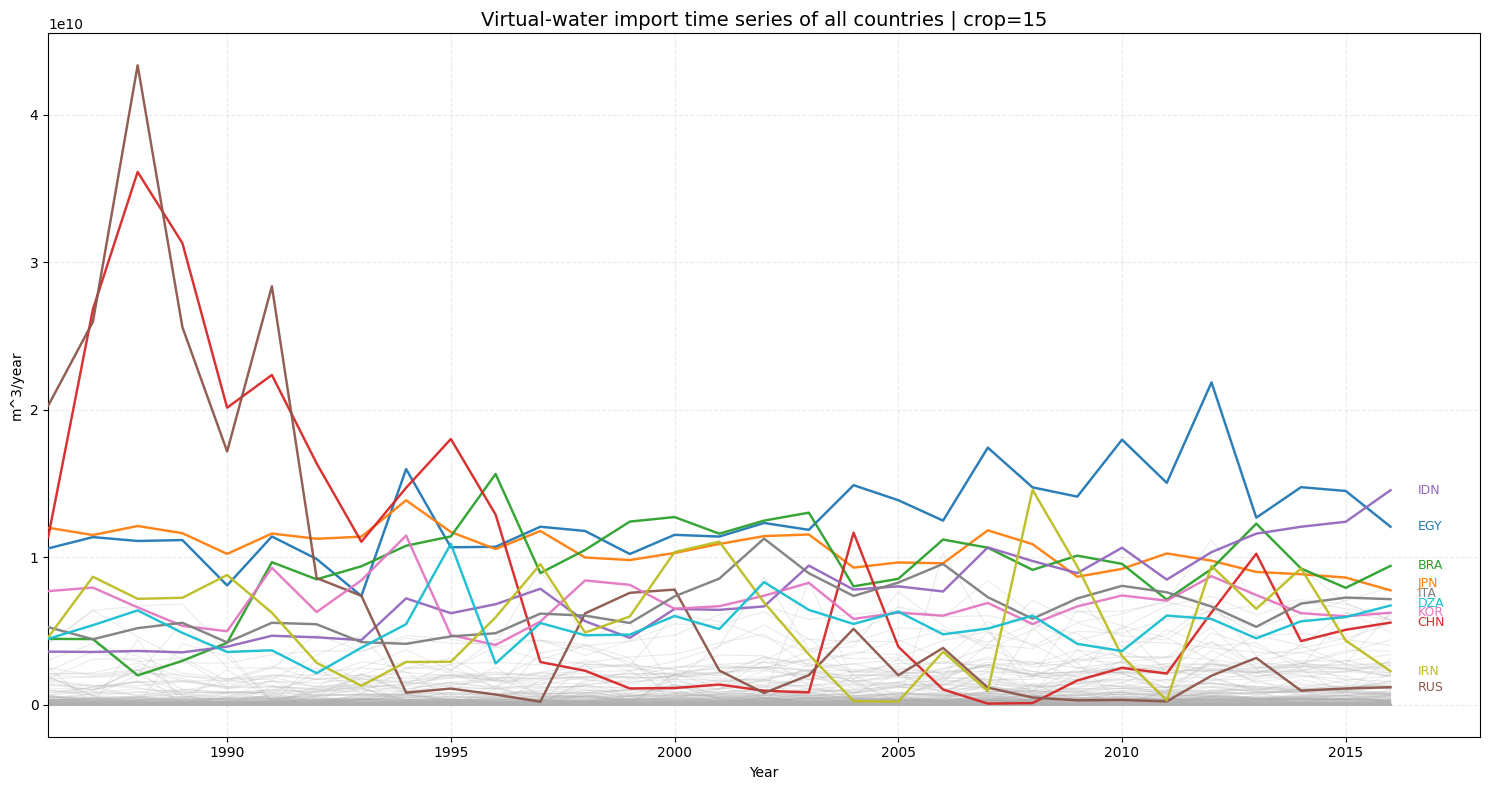

In [38]:
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"

df_long_imp, df_wide_imp = plot_vwt_import_timeseries_all_countries(
    crop=15,
    year_start=1986,
    year_end=2016,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    top_n_label=10,
)


# netバージョン

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_vwt_net_timeseries_all_countries(
    crop,
    year_start,
    year_end,
    country_list_xlsx,
    vwt_npy_template,
    unit="m^3/year",
    figsize=(15, 8),
    alpha=0.35,
    lw=0.8,
    ussr_until_year=1991,
    top_n_label=10,
    label_right_pad=0.6,
):
    """
    指定作物について、全ての国の net(import - export) 時系列を重ね描きする。
    前提: VWTmat は row=exporter, col=importer
    """
    USSR_ALIASES = {"USSR", "SUN", "USS"}
    USSR_NAME_ALIASES = {"USSR", "SOVIET UNION", "UNION OF SOVIET SOCIALIST REPUBLICS"}

    years = list(range(int(year_start), int(year_end) + 1))
    if len(years) == 0:
        raise ValueError("year_start <= year_end になるように指定して。")

    cl = pd.read_excel(country_list_xlsx)

    # ISO3列検出
    iso3_col = None
    for c in cl.columns:
        low = str(c).strip().lower()
        if low in ["iso3", "iso_a3", "iso-3", "iso_3"] or "iso3" in low:
            iso3_col = c
            break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    # 国名列検出
    country_name_col = None
    for c in cl.columns:
        low = str(c).strip().lower()
        if low in ["country name", "country", "name"]:
            country_name_col = c
            break
    if country_name_col is None:
        country_name_col = cl.columns[0]

    # N確定
    vwt0 = np.load(vwt_npy_template.format(crop=crop, year=years[0])).astype(float)
    if vwt0.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt0.shape}")

    N = min(vwt0.shape[0], vwt0.shape[1])
    if len(cl) < N:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({N}). country_listの行数が足りない。")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    ISO3_FIX = {
        "FR": "FRA",
        "UK": "GBR",
        "EL": "GRC",
        "SP": "ESP",
        "SW": "SWE",
        "NO": "NOR",
        "JA": "JPN",
        "KO": "KOR",
        "CH": "CHN",
    }
    clN["_iso3"] = clN["_iso3"].replace(ISO3_FIX)

    clN["_country"] = clN[country_name_col].astype(str).str.strip()
    clN["_country_upper"] = clN["_country"].str.upper()

    # ISO3欠損のUSSR補完
    missing_iso = clN["_iso3"].isin(["", "NAN", "NONE"])
    clN.loc[missing_iso & clN["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    # 年ごとのnet
    rows = []
    for y in years:
        VWTmat = np.load(vwt_npy_template.format(crop=crop, year=y)).astype(float)
        if VWTmat.ndim != 2:
            raise ValueError(f"年{y}のVWTmat must be 2D. got shape={VWTmat.shape}")

        VWTmat = VWTmat[:N, :N]
        import_totals = np.nansum(VWTmat, axis=0).astype(float)  # col sum
        export_totals = np.nansum(VWTmat, axis=1).astype(float)  # row sum
        net_totals = import_totals - export_totals

        tmp = pd.DataFrame({
            "year": y,
            "iso3": clN["_iso3"].values,
            "country": clN["_country"].values,
            "net": net_totals,
        })
        rows.append(tmp)

    df_long = pd.concat(rows, ignore_index=True)
    df_long["iso3"] = df_long["iso3"].astype(str).str.strip().str.upper()
    df_long["country"] = df_long["country"].astype(str).str.strip()

    # 無効ISO3除外
    df_long = df_long[~df_long["iso3"].isin(["", "NAN", "NONE"])].copy()

    # <=1991 は USSR/SUN/USS を RUS に統合
    pre_mask = df_long["year"] <= int(ussr_until_year)
    country_upper = df_long["country"].str.upper()

    is_ussr = df_long["iso3"].isin(USSR_ALIASES) | country_upper.isin(USSR_NAME_ALIASES)
    is_rus = df_long["iso3"].isin({"RUS", "RU"})

    years_with_ussr = set(df_long.loc[pre_mask & is_ussr, "year"].unique().tolist())

    # 同年にUSSRがあるpre期間のRUSは落として二重計上回避
    if len(years_with_ussr) > 0:
        drop_rus_mask = pre_mask & is_rus & df_long["year"].isin(years_with_ussr)
        df_long = df_long.loc[~drop_rus_mask].copy()

    replace_mask = pre_mask & is_ussr
    df_long.loc[replace_mask, "iso3"] = "RUS"
    df_long.loc[replace_mask, "country"] = "Russia"

    # 集計
    df_long = (
        df_long
        .groupby(["year", "iso3", "country"], as_index=False)["net"]
        .sum()
    )

    # ラベル順位は「期間中の絶対net合計」で決定
    rank_tbl = (
        df_long
        .groupby("iso3", as_index=False)["net"]
        .agg(abs_sum=lambda s: float(np.nansum(np.abs(s))))
        .sort_values("abs_sum", ascending=False)
    )

    valid_iso3 = rank_tbl.loc[rank_tbl["abs_sum"] > 0, "iso3"].tolist()
    df_long = df_long[df_long["iso3"].isin(valid_iso3)].copy()

    wide = df_long.pivot_table(
        index="year",
        columns="iso3",
        values="net",
        aggfunc="sum"
    )

    wide = wide.loc[:, ~wide.columns.duplicated()]
    ordered_iso3 = [x for x in rank_tbl["iso3"].tolist() if x in wide.columns]
    wide = wide[ordered_iso3]

    # ---- 描画 ----
    top_iso = ordered_iso3[:top_n_label]

    fig, ax = plt.subplots(figsize=figsize)

    top_colors_arr = plt.cm.tab10(np.linspace(0, 1, max(len(top_iso), 1)))
    top_color_map = {iso: top_colors_arr[i] for i, iso in enumerate(top_iso)}

    for iso3 in wide.columns:
        if iso3 in top_color_map:
            ax.plot(
                wide.index, wide[iso3],
                color=top_color_map[iso3],
                alpha=0.95,
                linewidth=lw * 2.2,
                zorder=3,
            )
        else:
            ax.plot(
                wide.index, wide[iso3],
                color="#B0B0B0",
                alpha=0.25,
                linewidth=lw,
                zorder=1,
            )

    ax.axhline(0.0, color="#444444", linewidth=1.0, linestyle="--", zorder=2)

    # 右端ラベル（上位のみ）
    label_rows = []
    for iso3 in top_iso:
        s = wide[iso3]
        if isinstance(s, pd.DataFrame):
            s = s.sum(axis=1)
        s = s.dropna().sort_index()
        if s.empty:
            continue
        x_last = int(s.index[-1])
        y_last = float(s.iloc[-1])
        label_rows.append([y_last, x_last, iso3])

    # 簡易重なり回避
    if len(label_rows) > 1:
        label_rows.sort(key=lambda x: x[0])
        ymin = float(np.nanmin(wide.to_numpy()))
        ymax = float(np.nanmax(wide.to_numpy()))
        min_sep = max((ymax - ymin) * 0.015, 1e-12)
        for i in range(1, len(label_rows)):
            if label_rows[i][0] - label_rows[i - 1][0] < min_sep:
                label_rows[i][0] = label_rows[i - 1][0] + min_sep

    for y_lab, x_last, iso3 in label_rows:
        ax.text(
            x_last + label_right_pad,
            y_lab,
            iso3,
            color=top_color_map[iso3],
            fontsize=9,
            va="center",
            ha="left",
            zorder=4,
        )

    ax.set_title(f"Virtual-water net (import - export) time series of all countries | crop={crop}", fontsize=14)
    ax.set_xlabel("Year")
    ax.set_ylabel(unit)
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_xlim(years[0], years[-1] + 2)

    plt.tight_layout()
    plt.show()

    return df_long, wide


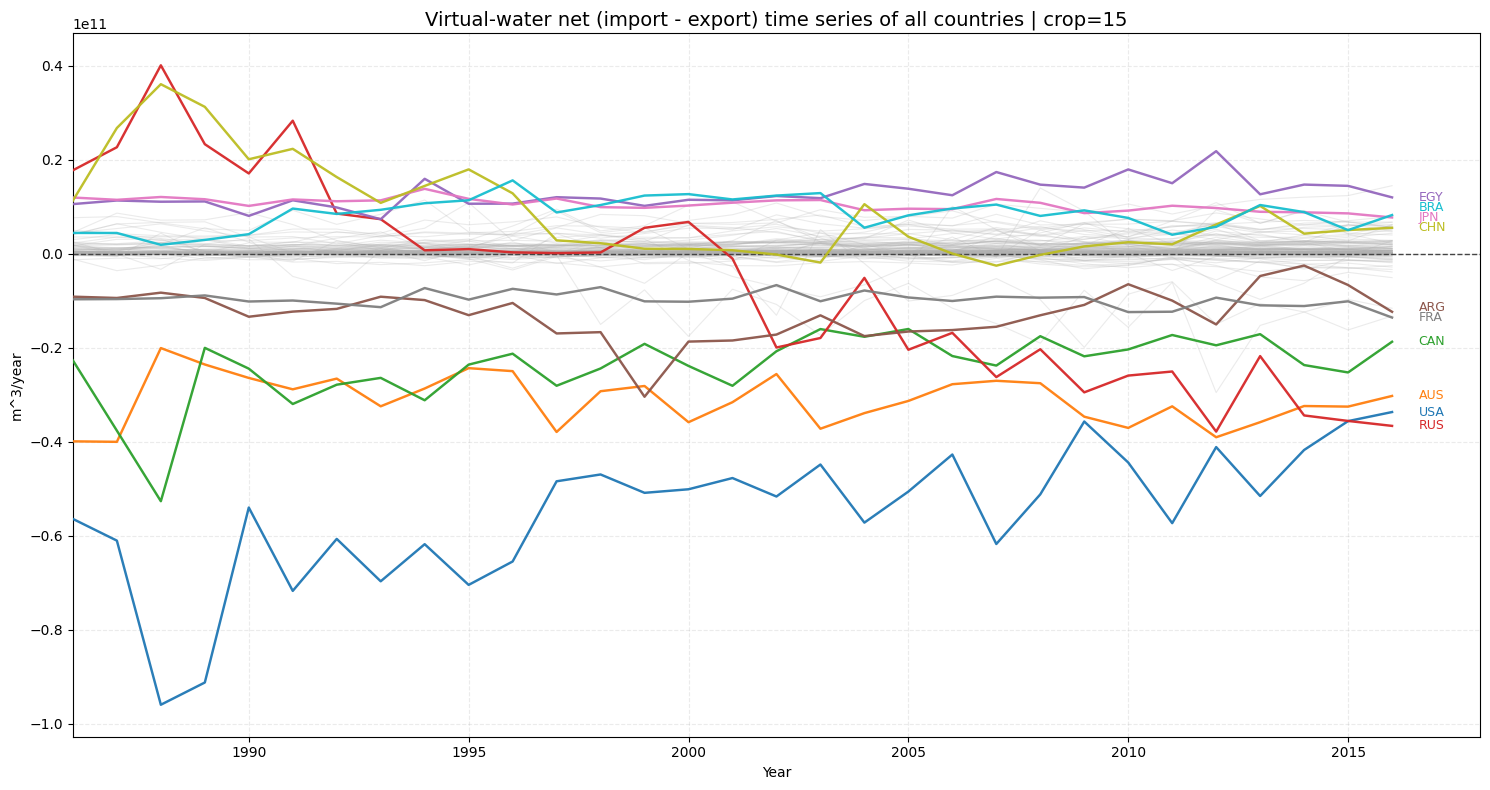

In [40]:
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"

df_long_net, df_wide_net = plot_vwt_net_timeseries_all_countries(
    crop=15,
    year_start=1986,
    year_end=2016,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    top_n_label=10,
)


# 貿易量総和

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_vwt_total_export_timeseries(
    crop,
    year_start,
    year_end,
    vwt_npy_template,
    unit="m^3/year",
    figsize=(12, 6),
    out_png=None,
):
    """
    指定した作物について、全世界の仮想水輸出量総和の時系列を描く。
    前提: VWTmat は row=exporter, col=importer
    """
    years = list(range(int(year_start), int(year_end) + 1))
    rows = []

    for y in years:
        vwt_path = vwt_npy_template.format(crop=crop, year=y)
        VWTmat = np.load(vwt_path).astype(float)

        if VWTmat.ndim != 2:
            raise ValueError(f"年{y}のVWTmat must be 2D. got shape={VWTmat.shape}")

        # 各国の輸出量
        export_by_country = np.nansum(VWTmat, axis=1)

        # 各国の輸出量の総和
        total_export = float(np.nansum(export_by_country))

        rows.append({
            "year": y,
            "total_export": total_export,
        })

    df_total = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df_total["year"], df_total["total_export"], color="#D55E00", linewidth=2.5)

    ax.set_title(f"Total virtual-water export time series | crop={crop}", fontsize=14)
    ax.set_xlabel("Year")
    ax.set_ylabel(unit)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_xlim(years[0], years[-1])

    plt.tight_layout()

    if out_png is not None:
        fig.savefig(out_png, dpi=200, bbox_inches="tight")
        print("Saved PNG:", out_png)

    plt.show()
    return df_total


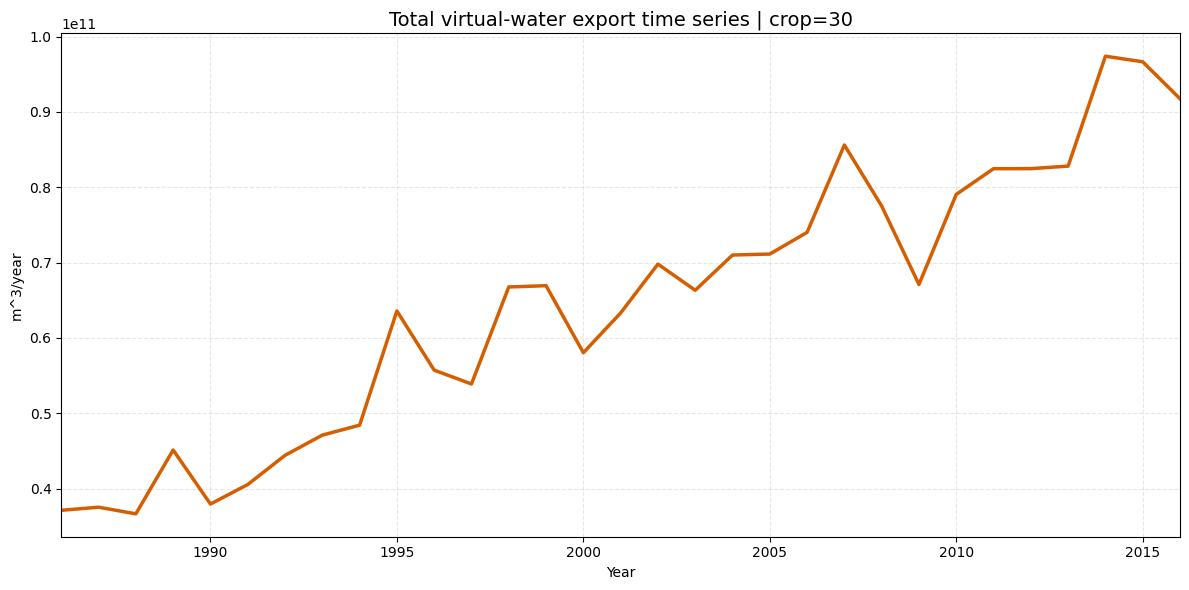

,year,total_export
0,1986,3.711373e+10
1,1987,3.752743e+10
2,1988,3.664515e+10
3,1989,4.512471e+10
4,1990,3.794470e+10


In [16]:
VWT_NPY_TEMPLATE = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"

df_total = plot_vwt_total_export_timeseries(
    crop=30,
    year_start=1986,
    year_end=2016,
    vwt_npy_template=VWT_NPY_TEMPLATE,
)

df_total.head()


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_vwt_total_import_timeseries(
    crop,
    year_start,
    year_end,
    vwt_npy_template,
    unit="m^3/year",
    figsize=(12, 6),
    out_png=None,
):
    """
    指定した作物について、全世界の仮想水輸入量総和の時系列を描く。
    前提: VWTmat は row=exporter, col=importer
    """
    years = list(range(int(year_start), int(year_end) + 1))
    rows = []

    for y in years:
        vwt_path = vwt_npy_template.format(crop=crop, year=y)
        VWTmat = np.load(vwt_path).astype(float)

        if VWTmat.ndim != 2:
            raise ValueError(f"年{y}のVWTmat must be 2D. got shape={VWTmat.shape}")

        # 各国の輸入量（列和）
        import_by_country = np.nansum(VWTmat, axis=0)

        # 各国の輸入量の総和
        total_import = float(np.nansum(import_by_country))

        rows.append({
            "year": y,
            "total_import": total_import,
        })

    df_total = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df_total["year"], df_total["total_import"], color="#0072B2", linewidth=2.5)

    ax.set_title(f"Total virtual-water import time series | crop={crop}", fontsize=14)
    ax.set_xlabel("Year")
    ax.set_ylabel(unit)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_xlim(years[0], years[-1])

    plt.tight_layout()

    if out_png is not None:
        fig.savefig(out_png, dpi=200, bbox_inches="tight")
        print("Saved PNG:", out_png)

    plt.show()
    return df_total


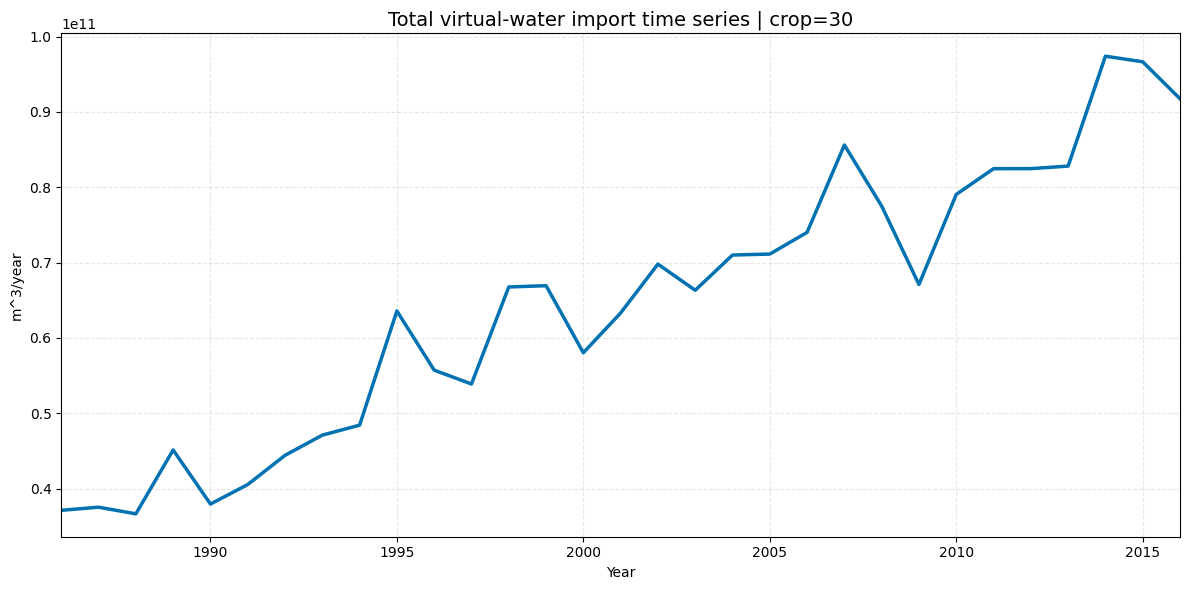

,year,total_import
0,1986,3.711373e+10
1,1987,3.752743e+10
2,1988,3.664515e+10
3,1989,4.512471e+10
4,1990,3.794470e+10


In [42]:
VWT_NPY_TEMPLATE = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"

df_total = plot_vwt_total_import_timeseries(
    crop=30,
    year_start=1986,
    year_end=2016,
    vwt_npy_template=VWT_NPY_TEMPLATE,
)

df_total.head()


# 単位生産に必要な水の量

Matrix shape=(255, 56), selected columns=30 (1987..2016)
Global scale: [0, 18080.2]
Saved GIF: C:\修論研究\VWT_historical_data\uWFp_item15_1987_2016_map.gif


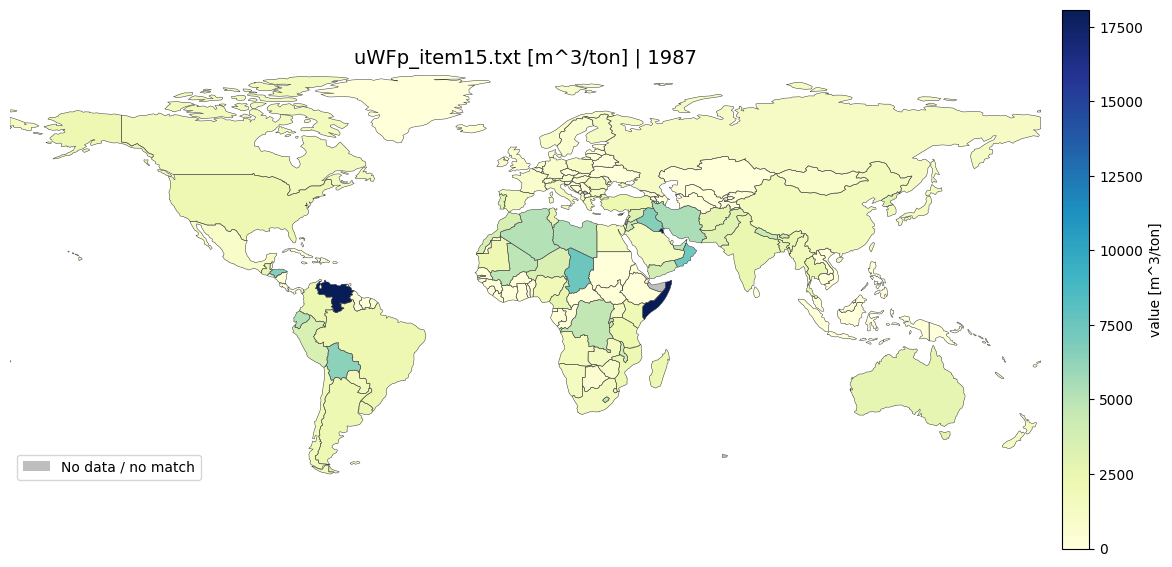

In [1]:
from percapita_utils import animate_uwfp_item_map

anim = animate_uwfp_item_map(
    item_id=15,
    uwfp_zip_path=r"C:\修論研究\VWT_historical_data\uWFp_primary_crops.zip",
    country_list_xlsx=r"C:\修論研究\VWT_historical_data\country_list.xlsx",
    ne_countries_shp=r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp",
    column_start_year=1961,   # uWFp列の先頭年（通常1961）
    year_start=1987,          # 30年にしたい場合の例
    year_end=2016,            # 1987-2016で30年
    # または last_n_years=30 でもOK
    out_gif=r"C:\修論研究\VWT_historical_data\uWFp_item15_1987_2016_map.gif",
    fps=6,
    cmap="YlGnBu",
    clip_quantile=0.995,
)
